<a href="https://colab.research.google.com/github/hyang0129/NGAFIDDATASET/blob/main/NGAFID_DATASET_MINIROCKET_EXAMPLE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!python --version

Python 3.12.12


In [2]:
!git clone https://github.com/ccDT2022/NGAFIDDATASET.git

!(cd NGAFIDDATASET ; git checkout main; git reset --hard HEAD; git pull)
!(cd NGAFIDDATASET ; pip install -r requirements.txt -q)

!pip install tsai -q

fatal: destination path 'NGAFIDDATASET' already exists and is not an empty directory.
Already on 'main'
Your branch is up to date with 'origin/main'.
HEAD is now at 2b2c04e Update dataset.py
Already up to date.


In [3]:
# 1. 导入必要的系统库
import sys
import importlib

# 2. 打补丁：将 importlib 伪装成 Python 3.12 中已经被移除的 imp 模块
sys.modules['imp'] = importlib

# 3. 补充原代码逻辑：将下载好的数据集项目路径添加到系统环境变量中
sys.path.append('/content/NGAFIDDATASET')

# 4. 此时系统里已经有了一个“假”的 imp，可以安全地加载 autoreload 扩展了
%load_ext autoreload

In [4]:
%autoreload
from ngafiddataset.dataset.dataset import NGAFID_Dataset_Manager
from ngafiddataset.utils import connect_to_tpu

from tsai.basics import *
from tsai.models.MINIROCKET_Pytorch import *
from tsai.models.utils import *
import pandas as pd


# strategy = connect_to_tpu()

/content/NGAFIDDATASET/ngafiddataset/dataset/dataset.py:6: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [5]:
# 1. 删除刚才下载失败的“伪装网页”文件
!rm -f /content/2days.tar.gz
!rm -rf /content/2days

# 2. 使用正确的直接下载接口，强制下载 2days 数据集
!gdown "https://drive.google.com/uc?id=1OlvdT5xk9-mvFnlhfXYydxRnEUtVe-yH" -O /content/2days.tar.gz

# 3. 将下载好的压缩包解压到当前目录
!tar -xzf /content/2days.tar.gz -C /content/

print("✅ 2days 数据集下载并解压完成！")

# 4. 继续运行原本的数据加载逻辑（此时不让 dm 去重复下载和解压）
from ngafiddataset.dataset.dataset import NGAFID_Dataset_Manager
import pandas as pd

dm = NGAFID_Dataset_Manager('2days', extract=False) # 加上 extract=False 防止它再次尝试解压报错
df = pd.read_csv('/content/2days/flight_header.csv', index_col = 'Master Index')

# 构建数据字典
dm.data_dict = dm.construct_data_dictionary(numpy=True)


Downloading...
From (original): https://drive.google.com/uc?id=1OlvdT5xk9-mvFnlhfXYydxRnEUtVe-yH
From (redirected): https://drive.google.com/uc?id=1OlvdT5xk9-mvFnlhfXYydxRnEUtVe-yH&confirm=t&uuid=770c02df-e152-4242-963e-894faab214cc
To: /content/2days.tar.gz
100% 1.13G/1.13G [00:05<00:00, 197MB/s]
✅ 2days 数据集下载并解压完成！


  0%|          | 0/11446 [00:00<?, ?it/s]

In [6]:
df.head(5)

,before_after,date_diff,flight_length,label,hierarchy,fold,class,target_class,hclass,number_flights_before
Master Index,,,,,,,,,,
1,1,-1,4723.0,intake gasket leak/damage,NaN,0,10,10,0,0
2,1,-2,4649.0,intake gasket leak/damage,NaN,0,10,10,0,3
7,0,1,3482.0,intake gasket leak/damage,NaN,0,10,0,0,-1
9,1,-1,4979.0,intake gasket leak/damage,NaN,0,10,10,0,0
11,0,2,5204.0,intake gasket leak/damage,NaN,0,10,0,0,-1


In [7]:
number_classes = len(dm.flight_header_df['class'].unique())
number_classes

number_hierarchies = len(dm.flight_header_df['hclass'].unique())
number_hierarchies


5

In [8]:
from fastai.vision import *

In [9]:

from fastai.callback.progress import CSVLogger

# from fastai.callbacks import CSVLogger
from tqdm.autonotebook import tqdm

  0%|          | 0/5 [00:00<?, ?it/s]


--- 正在处理 Fold 0 ---
内存限制：原本有 9156 条训练数据，现截取前 915 条


epoch,train_loss,valid_loss,accuracy,time
0,0.693056,0.692266,0.480349,00:00
1,0.689490,0.692594,0.506550,00:00
2,0.683435,0.690509,0.506550,00:00
3,0.675933,0.692595,0.541485,00:00
4,0.671091,0.693061,0.541485,00:00


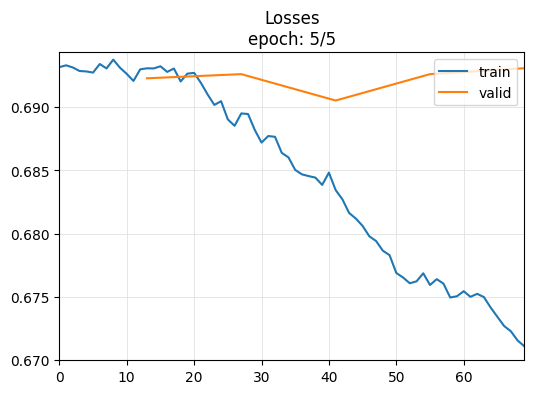

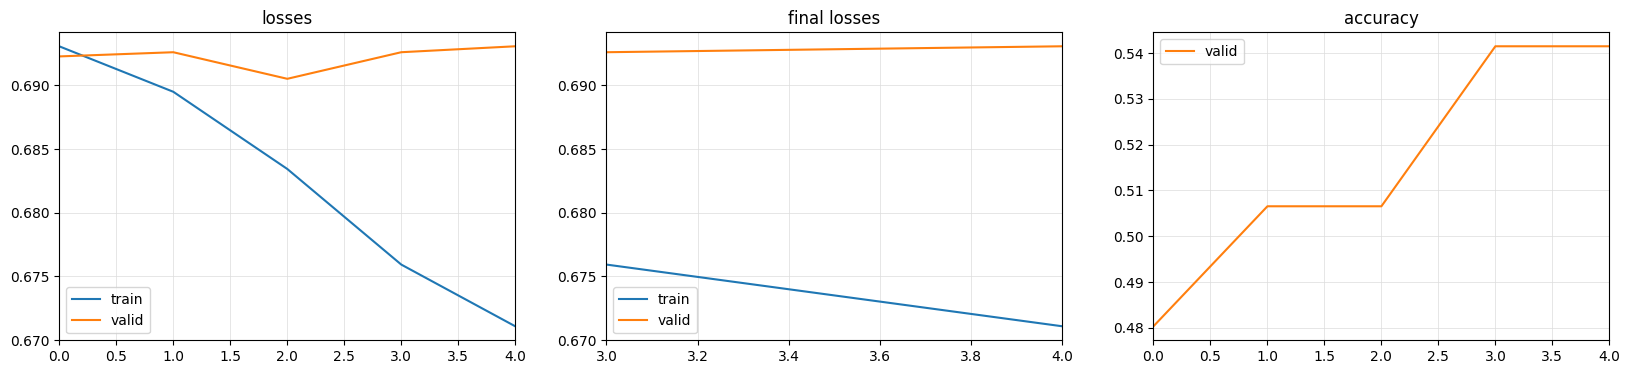


--- 正在处理 Fold 1 ---
内存限制：原本有 9157 条训练数据，现截取前 915 条


epoch,train_loss,valid_loss,accuracy,time
0,0.693196,0.691349,0.561404,00:00
1,0.686574,0.686589,0.570175,00:00
2,0.677674,0.681179,0.552632,00:00
3,0.669445,0.680332,0.570175,00:00
4,0.663312,0.680204,0.565789,00:00


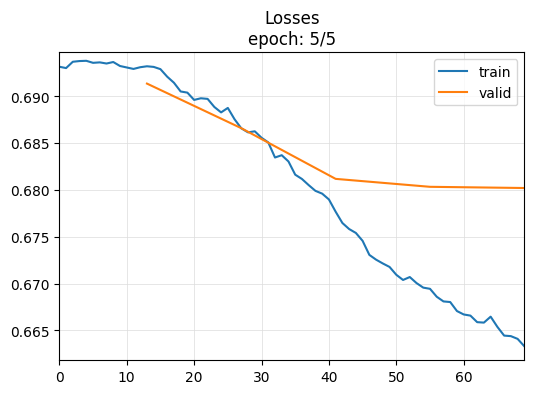

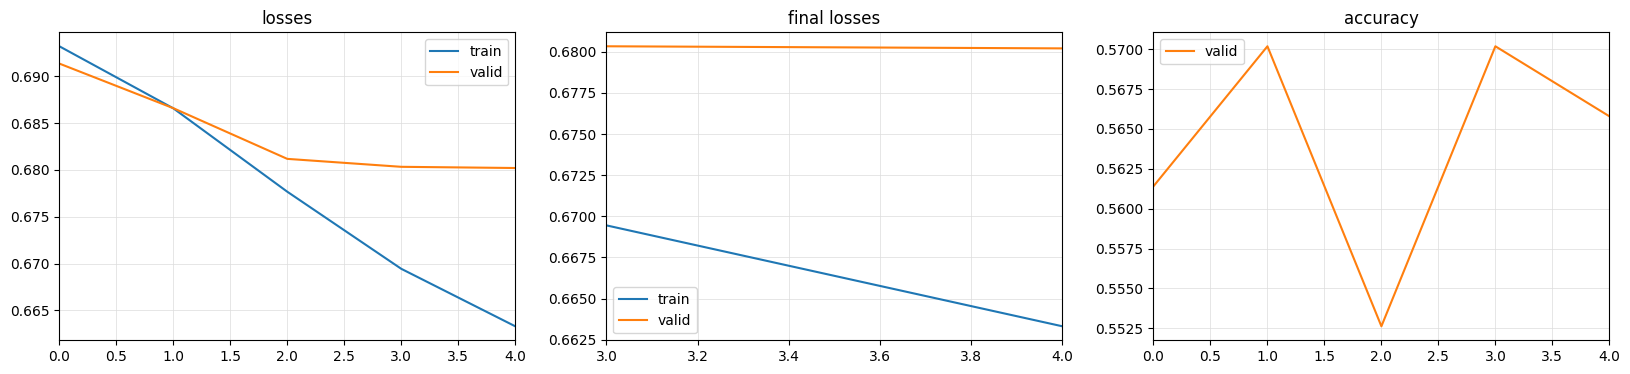


--- 正在处理 Fold 2 ---
内存限制：原本有 9157 条训练数据，现截取前 915 条


epoch,train_loss,valid_loss,accuracy,time
0,0.693811,0.693991,0.486842,00:00
1,0.688257,0.694905,0.486842,00:00
2,0.681176,0.691645,0.521930,00:00
3,0.672935,0.692055,0.513158,00:00
4,0.666780,0.692170,0.517544,00:00


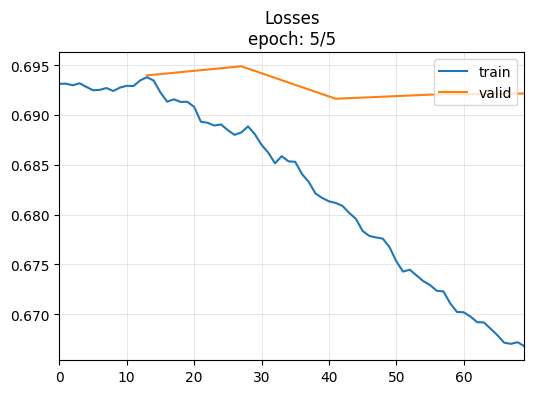

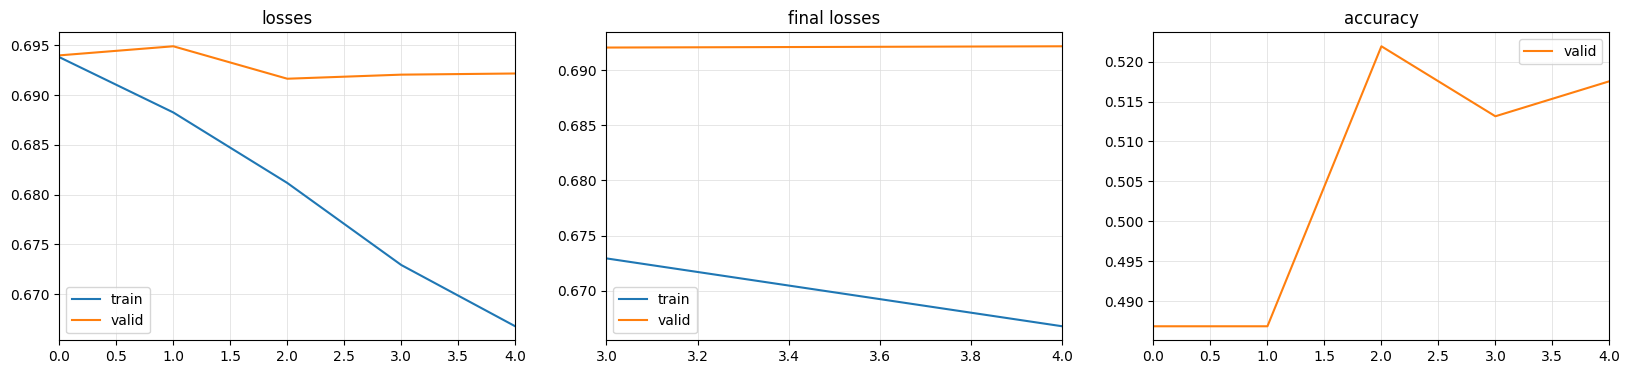


--- 正在处理 Fold 3 ---
内存限制：原本有 9157 条训练数据，现截取前 915 条


epoch,train_loss,valid_loss,accuracy,time
0,0.692776,0.684419,0.697368,00:00
1,0.688559,0.679143,0.605263,00:00
2,0.680374,0.680248,0.535088,00:00
3,0.673127,0.668377,0.543860,00:00
4,0.667462,0.667575,0.543860,00:00


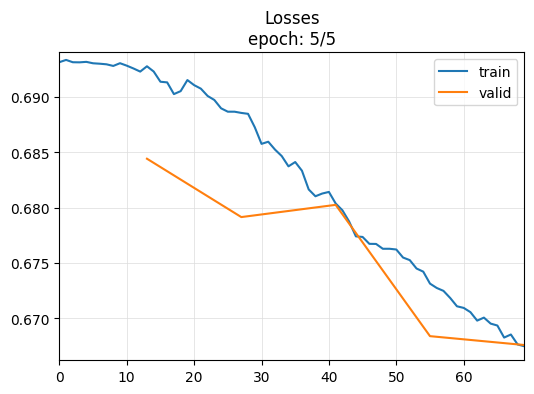

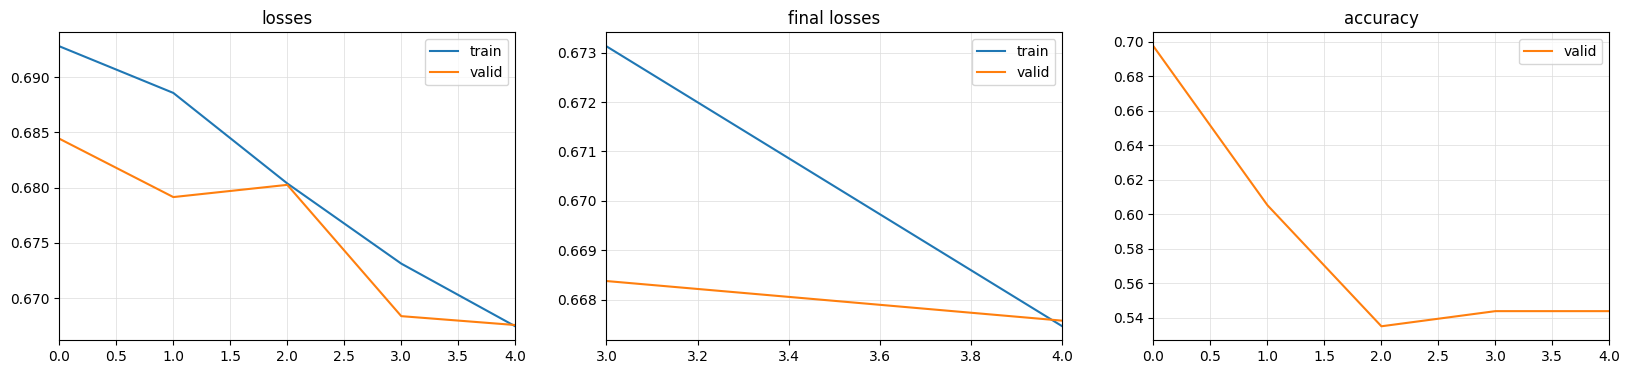


--- 正在处理 Fold 4 ---
内存限制：原本有 9157 条训练数据，现截取前 915 条


epoch,train_loss,valid_loss,accuracy,time
0,0.692674,0.687131,0.723684,00:00
1,0.688086,0.699741,0.473684,00:00
2,0.680705,0.684345,0.565789,00:00
3,0.672173,0.686798,0.561404,00:00
4,0.665770,0.691247,0.543860,00:00


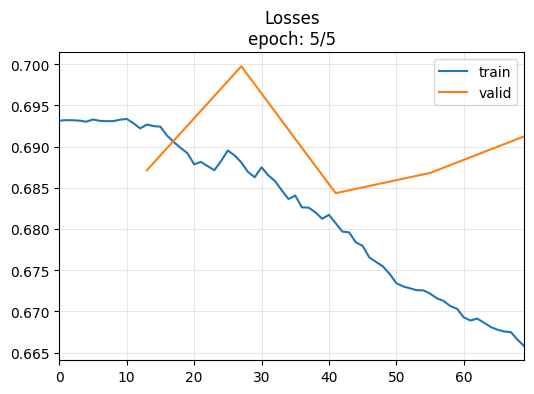

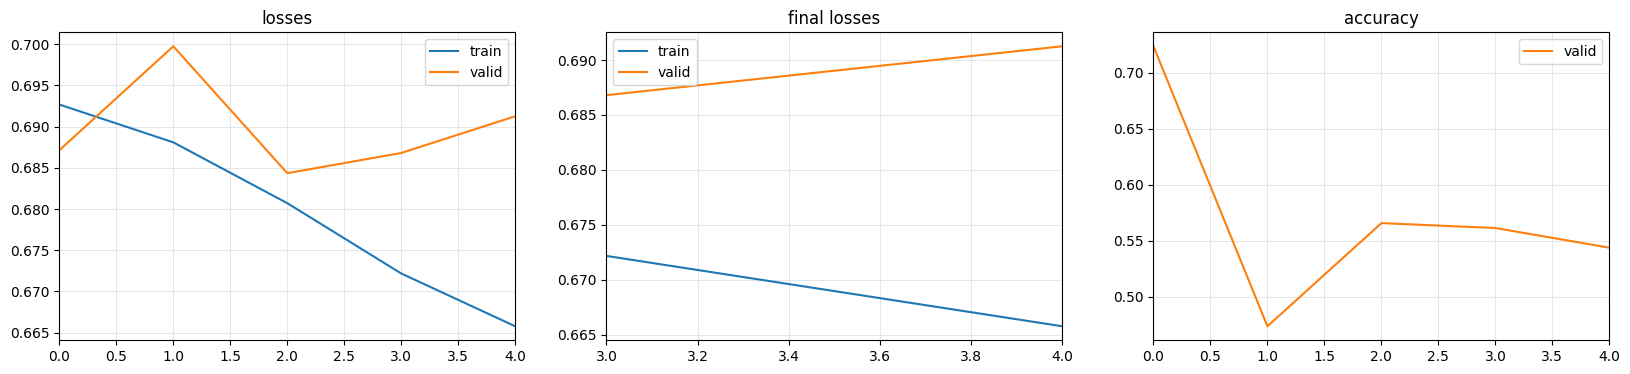

In [10]:
import gc

save_path = '.'
model_name = 'MINIROCKET_MULTI'

# 设置一个采样比例，比如 0.1 代表只用 10% 的数据跑测试
SAMPLE_RATIO = 0.1

for fold in tqdm(range(5)):
    print(f"\n--- 正在处理 Fold {fold} ---")

    torch.cuda.empty_cache()
    gc.collect()

    save_filename = save_path + '%s_%i' % (model_name, fold)

    # 1. 获取数据字典
    train_dict = dm.get_numpy_dataset(fold=fold, training=True)
    test_dict = dm.get_numpy_dataset(fold=fold, training=False)

    # 2. 计算我们要截取的数据量 (前 10%)
    train_limit = max(1, int(len(train_dict['data']) * SAMPLE_RATIO))
    test_limit = max(1, int(len(test_dict['data']) * SAMPLE_RATIO))
    print(f"内存限制：原本有 {len(train_dict['data'])} 条训练数据，现截取前 {train_limit} 条")

    # 3. 只将截取后的数据转换为 Numpy 数组
    train_X = np.array(train_dict['data'][:train_limit], dtype=np.float32)
    test_X = np.array(test_dict['data'][:test_limit], dtype=np.float32)

    train_Y = np.array(train_dict['target_class'][:train_limit])
    test_Y = np.array(test_dict['target_class'][:test_limit])

    # 4. 立刻删除原始大字典并回收内存
    del train_dict, test_dict
    gc.collect()

    # 就地归一化
    train_X -= dm.mins
    train_X /= (dm.maxs - dm.mins)
    np.nan_to_num(train_X, copy=False)

    test_X -= dm.mins
    test_X /= (dm.maxs - dm.mins)
    np.nan_to_num(test_X, copy=False)

    splits = [list(np.arange(len(train_Y))), list(np.arange(len(test_Y)) + len(train_Y))]

    mrf = MiniRocketFeatures(train_X.shape[1], train_X.shape[2]).to(default_device())

    # 进一步缩小 chunksize 降低内存峰值
    chunksize = 32
    mrf.fit(train_X, chunksize=chunksize)

    X_combined = np.concatenate([train_X, test_X])
    Y_combined = np.concatenate([train_Y, test_Y])

    del train_X, test_X, train_Y, test_Y
    gc.collect()

    X_feat = get_minirocket_features(X_combined, mrf, chunksize=chunksize, to_np=True)

    del X_combined
    gc.collect()

    PATH = Path("./models/MRF.pt")
    PATH.parent.mkdir(parents=True, exist_ok=True)
    torch.save(mrf.state_dict(), PATH)

    tfms = [None, TSClassification()]
    batch_tfms = TSStandardize(by_sample=True)
    dls = get_ts_dls(X_feat, Y_combined, splits=splits, tfms=tfms, batch_tfms=batch_tfms)
    model = build_ts_model(MiniRocketHead, dls=dls)

    learn = Learner(dls, model, metrics=accuracy, cbs=[ShowGraph(), CSVLogger(save_filename)])

    # 因为数据少了，可以先只跑 5 个 Epoch 快速看结果
    results = learn.fit_one_cycle(5, 2.5e-5)

    del dls, model, learn, X_feat, Y_combined, mrf
    gc.collect()
    torch.cuda.empty_cache()

    # 如果只想验证跑通，可以在跑完 Fold 0 后强行 break 退出循环
    # break